In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.pyplot import MultipleLocator
import os
# os.environ["PATH"] = "/apps/spack/anvil/apps/texlive/20200406-gcc-11.2.0-eeavxnm/bin/x86_64-linux:/Library/TeX/texbin:" + os.environ.get("PATH","")
from scipy.stats import gaussian_kde
from PIL import Image
import numpy as np

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    # ---------- LaTeX ----------
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # ---------- Font sizes ----------
    "font.size": 24,            # 全局默认字号
    "axes.labelsize": 24,       # 坐标轴标题
    "axes.titlesize": 24,       # 子图标题
    "xtick.labelsize": 24,      # x 轴刻度
    "ytick.labelsize": 24,      # y 轴刻度
    "legend.fontsize": 24,      # 图例字号
    "legend.title_fontsize": 24,

    # ---------- Axes ----------
    "axes.linewidth": 1.2,      # 坐标轴边框线宽
    "axes.unicode_minus": False,

    # ---------- Lines ----------
    "lines.linewidth": 2.0,
    "lines.markersize": 8,

    # ---------- Ticks ----------
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,

    # ---------- Legend ----------
    "legend.frameon": False,    # 论文图通常不用边框
    "legend.handlelength": 1.8,
    "legend.handletextpad": 0.4,
    "legend.borderpad": 0.3,
    "legend.labelspacing": 0.3,

    # ---------- Figure ----------
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    # ---------- PDF/PS ----------
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

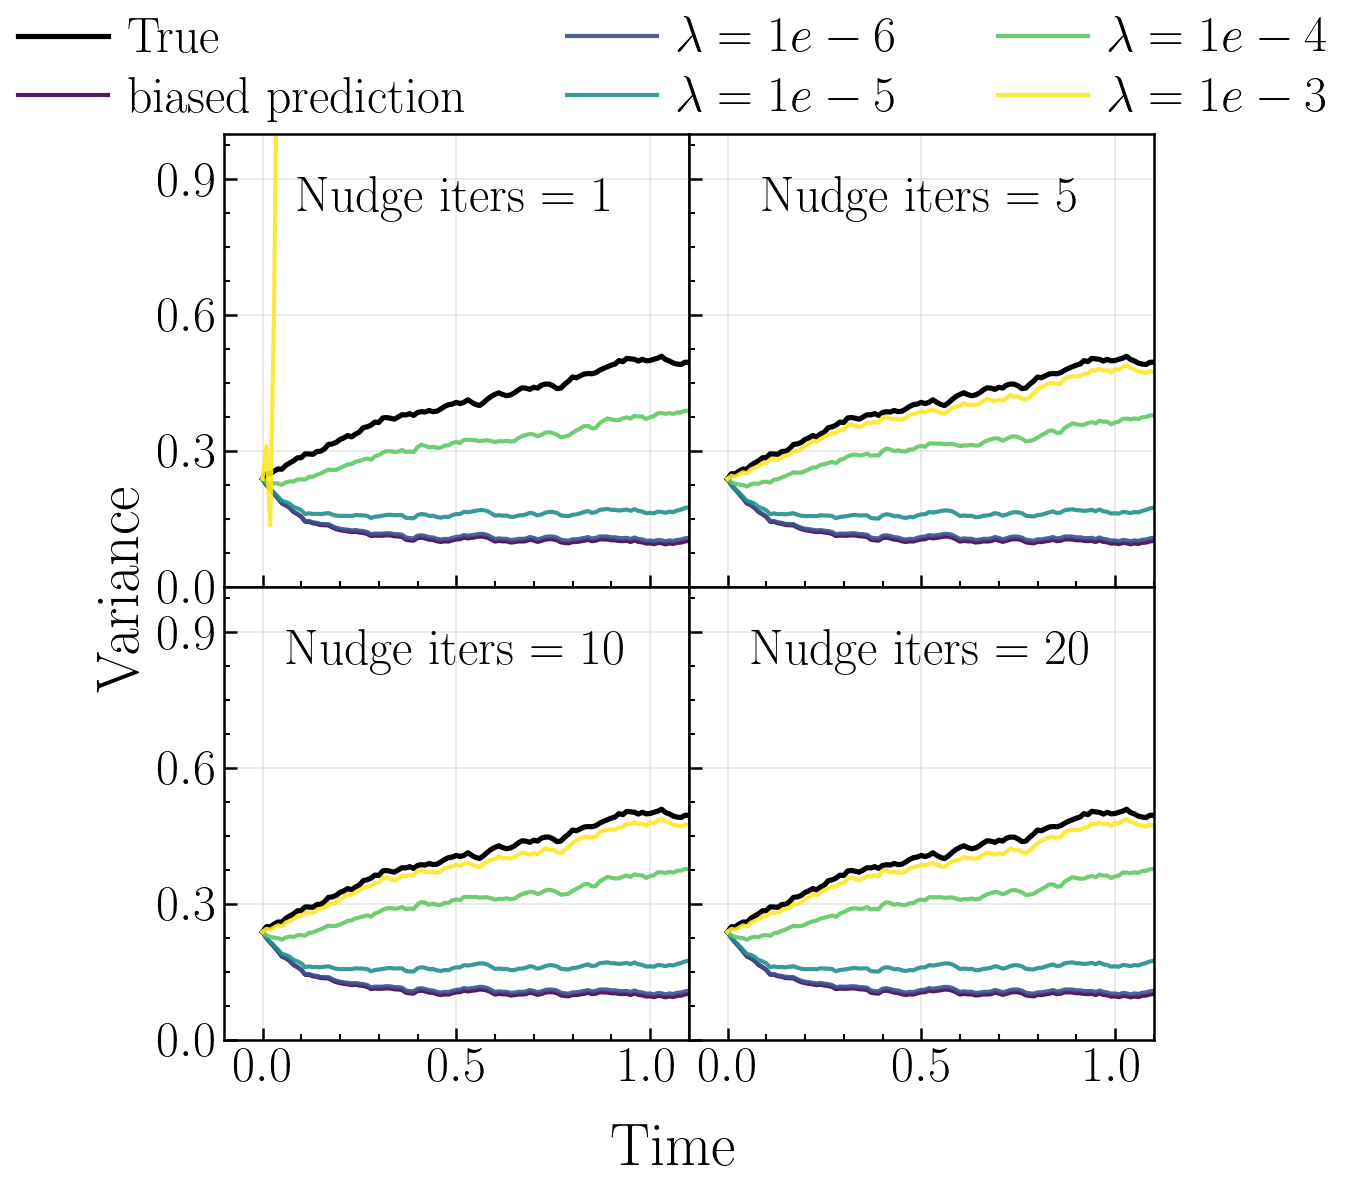

In [3]:
nudge_list = [1, 5, 10, 20]
lambda_list = [
    ("001_0p000e00", "0"),
    ("003_1p000e-06", "1e-6"),
    ("004_1p000e-05", "1e-5"),
    ("005_1p000e-04", "1e-4"),
    ("006_1p000e-03", "1e-3"),
]

# 真值（只需要读一次）
data_true = np.load("../case1d/simulation/data/mv_sim_seed0.npz")
times = data_true["times"]
var_true = np.var(data_true["x_paths"], axis=-1)

# colormap
colors = plt.cm.viridis(np.linspace(0, 1, len(lambda_list)))

fig, axes = plt.subplots(
    2, 2, figsize=(8, 8), sharex=True, sharey=True,
    gridspec_kw={"wspace": 0, "hspace": 0}
)
axes = axes.flatten()

for idx, nudge in enumerate(nudge_list):
    ax = axes[idx]

    # 画真值
    ax.plot(times, var_true, color='black', linewidth=2.5, label='True')

    # 画不同 lambda
    for (lam_str, lam_label), c in zip(lambda_list, colors):
        path = f"../case1d/assimilation/data/lambda_scan_parameter_grid/a_5p000e00__nudge_iters_{nudge:03d}/lambda_scan/runs/lambda_{lam_str}/x_da_kdenudge_1d_seed0.npz"
        data = np.load(path)
        var_est = np.var(data["x_est"], axis=-1)
        if lam_label == "0":
            ax.plot(times, var_est, color=c, alpha=0.9, label="biased prediction")
        else:
            ax.plot(times, var_est, color=c, alpha=0.9, label=f"$\\lambda={lam_label}$")
    ax.set_ylim([0,1])
    ax.set_xlim([-0.1,1.1])
    ax.set_yticks([0.0,0.3,0.6,0.9])
    ax.set_title(f"Nudge iters = {nudge}",y=0.8)
    ax.grid(alpha=0.3)

# 统一 legend（避免重复）
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, ncol=3,
           loc='upper center',
           bbox_to_anchor=(0.5, 1.01))

fig.supxlabel("Time")
fig.supylabel("Variance")

plt.savefig("1d_case_a_0.5.pdf",dpi=600)
plt.savefig("1d_case_a_0.5.png",dpi=600)

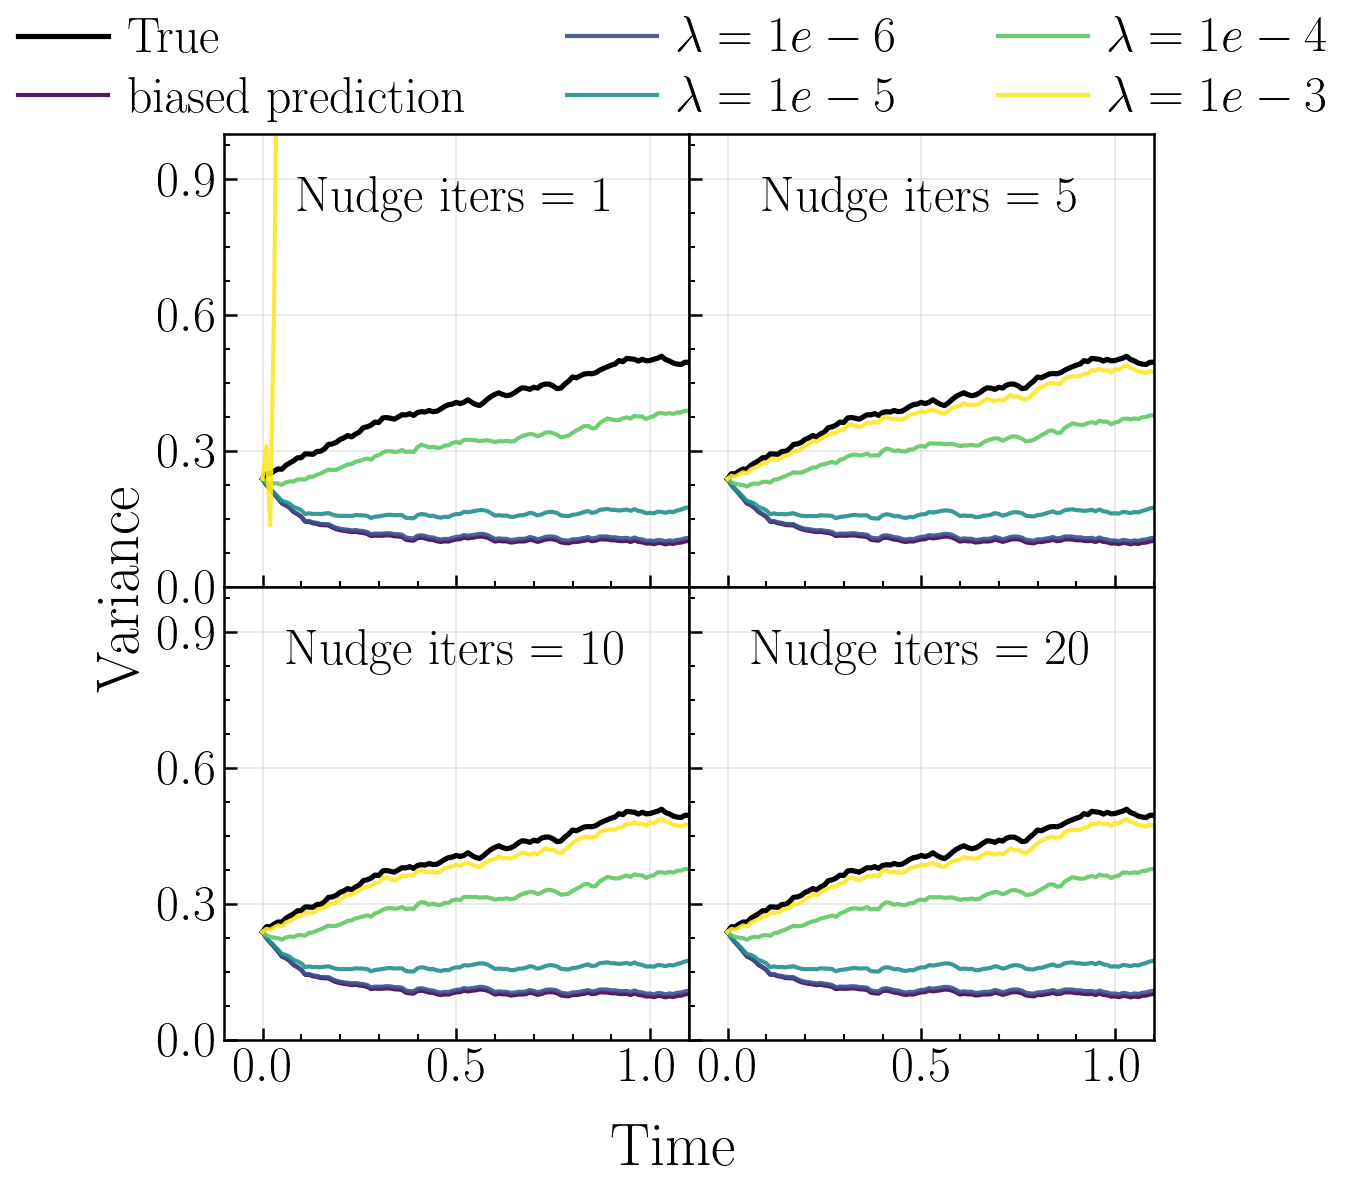

In [4]:
nudge_list = [1, 5, 10, 20]
lambda_list = [
    ("001_0p000e00", "0"),
    ("003_1p000e-06", "1e-6"),
    ("004_1p000e-05", "1e-5"),
    ("005_1p000e-04", "1e-4"),
    ("006_1p000e-03", "1e-3"),
]

# 真值（只需要读一次）
data_true = np.load("../case1d/simulation/data/mv_sim_seed0.npz")
times = data_true["times"]
var_true = np.var(data_true["x_paths"], axis=-1)

# colormap
colors = plt.cm.viridis(np.linspace(0, 1, len(lambda_list)))

fig, axes = plt.subplots(
    2, 2, figsize=(8, 8), sharex=True, sharey=True,
    gridspec_kw={"wspace": 0, "hspace": 0}
)
axes = axes.flatten()

for idx, nudge in enumerate(nudge_list):
    ax = axes[idx]

    # 画真值
    ax.plot(times, var_true, color='black', linewidth=2.5, label='True')

    # 画不同 lambda
    for (lam_str, lam_label), c in zip(lambda_list, colors):
        path = f"../case1d/assimilation/data/lambda_scan_parameter_grid/a_5p000e00__nudge_iters_{nudge:03d}/lambda_scan/runs/lambda_{lam_str}/x_da_kdenudge_1d_seed0.npz"
        data = np.load(path)
        var_est = np.var(data["x_est"], axis=-1)
        if lam_label == "0":
            ax.plot(times, var_est, color=c, alpha=0.9, label="biased prediction")
        else:
            ax.plot(times, var_est, color=c, alpha=0.9, label=f"$\\lambda={lam_label}$")
    ax.set_ylim([0,1])
    ax.set_xlim([-0.1,1.1])
    ax.set_yticks([0.0,0.3,0.6,0.9])
    ax.set_title(f"Nudge iters = {nudge}",y=0.8)
    ax.grid(alpha=0.3)

# 统一 legend（避免重复）
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, ncol=3,
           loc='upper center',
           bbox_to_anchor=(0.5, 1.01))

fig.supxlabel("Time")
fig.supylabel("Variance")

plt.savefig("1d_case_a_5.pdf",dpi=600)
plt.savefig("1d_case_a_5.png",dpi=600)

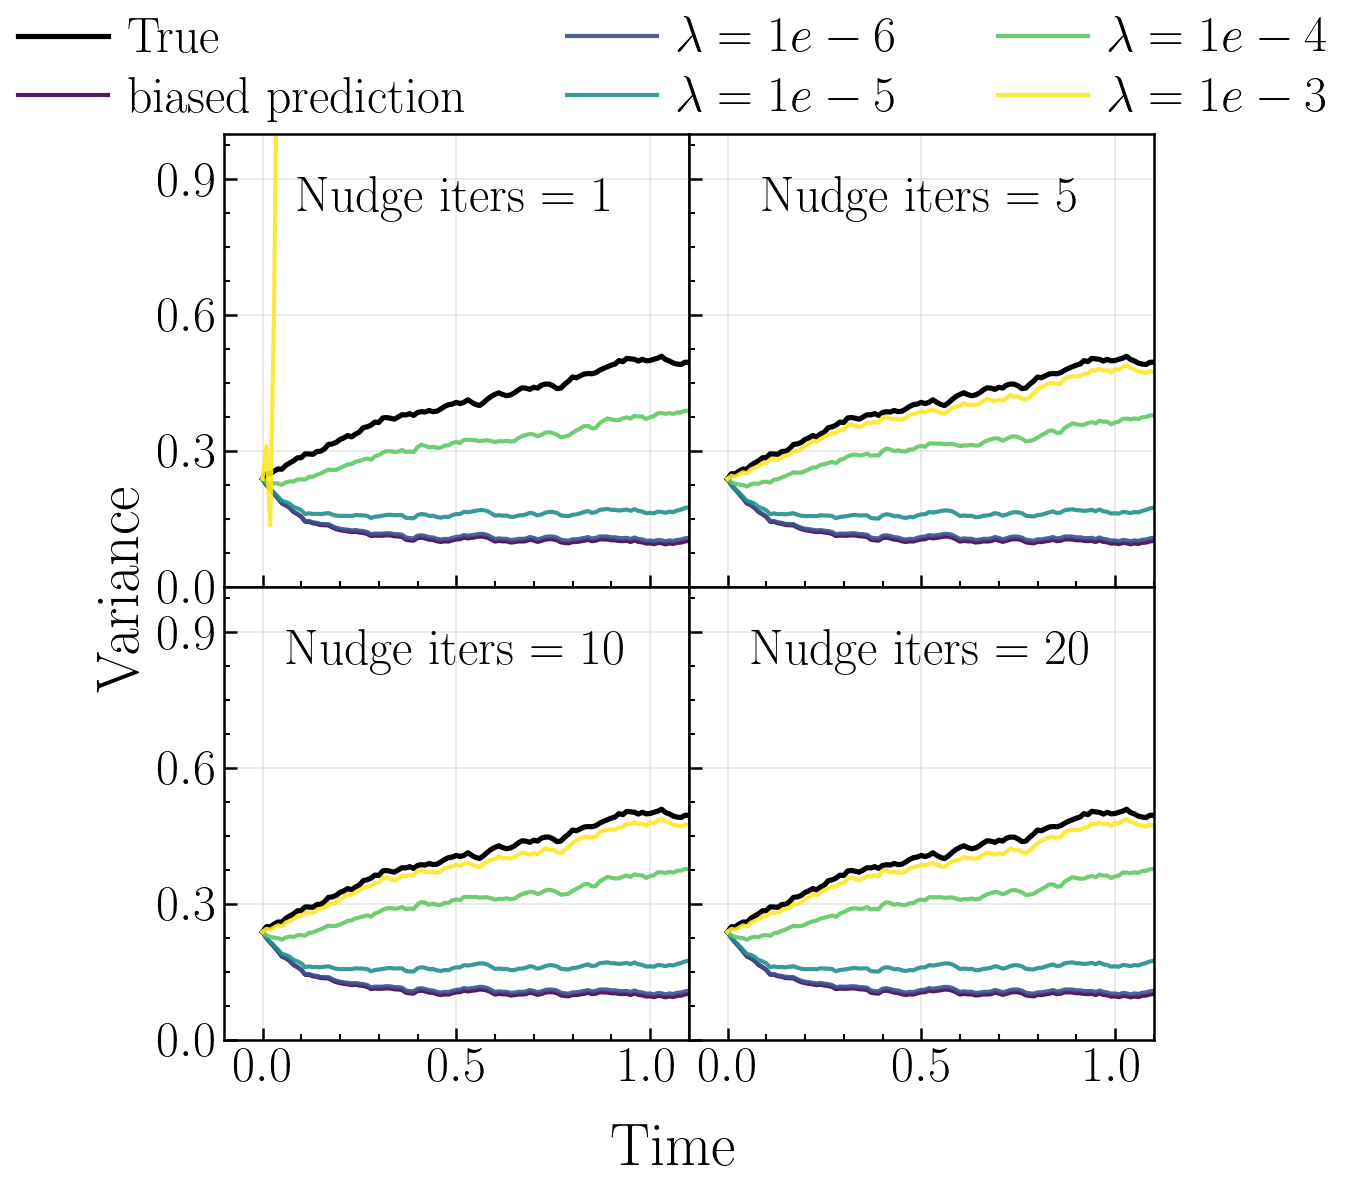

In [5]:
nudge_list = [1, 5, 10, 20]
lambda_list = [
    ("001_0p000e00", "0"),
    ("003_1p000e-06", "1e-6"),
    ("004_1p000e-05", "1e-5"),
    ("005_1p000e-04", "1e-4"),
    ("006_1p000e-03", "1e-3"),
]

# 真值（只需要读一次）
data_true = np.load("../case1d/simulation/data/mv_sim_seed0.npz")
times = data_true["times"]
var_true = np.var(data_true["x_paths"], axis=-1)

# colormap
colors = plt.cm.viridis(np.linspace(0, 1, len(lambda_list)))

fig, axes = plt.subplots(
    2, 2, figsize=(8, 8), sharex=True, sharey=True,
    gridspec_kw={"wspace": 0, "hspace": 0}
)
axes = axes.flatten()

for idx, nudge in enumerate(nudge_list):
    ax = axes[idx]

    # 画真值
    ax.plot(times, var_true, color='black', linewidth=2.5, label='True')

    # 画不同 lambda
    for (lam_str, lam_label), c in zip(lambda_list, colors):
        path = f"../case1d/assimilation/data/lambda_scan_parameter_grid/a_5p000e00__nudge_iters_{nudge:03d}/lambda_scan/runs/lambda_{lam_str}/x_da_kdenudge_1d_seed0.npz"
        data = np.load(path)
        var_est = np.var(data["x_est"], axis=-1)
        if lam_label == "0":
            ax.plot(times, var_est, color=c, alpha=0.9, label="biased prediction")
        else:
            ax.plot(times, var_est, color=c, alpha=0.9, label=f"$\\lambda={lam_label}$")
    ax.set_ylim([0,1])
    ax.set_xlim([-0.1,1.1])
    ax.set_yticks([0.0,0.3,0.6,0.9])
    ax.set_title(f"Nudge iters = {nudge}",y=0.8)
    ax.grid(alpha=0.3)

# 统一 legend（避免重复）
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, ncol=3,
           loc='upper center',
           bbox_to_anchor=(0.5, 1.01))

fig.supxlabel("Time")
fig.supylabel("Variance")

plt.savefig("1d_case_a_2.pdf",dpi=600)
plt.savefig("1d_case_a_2.png",dpi=600)

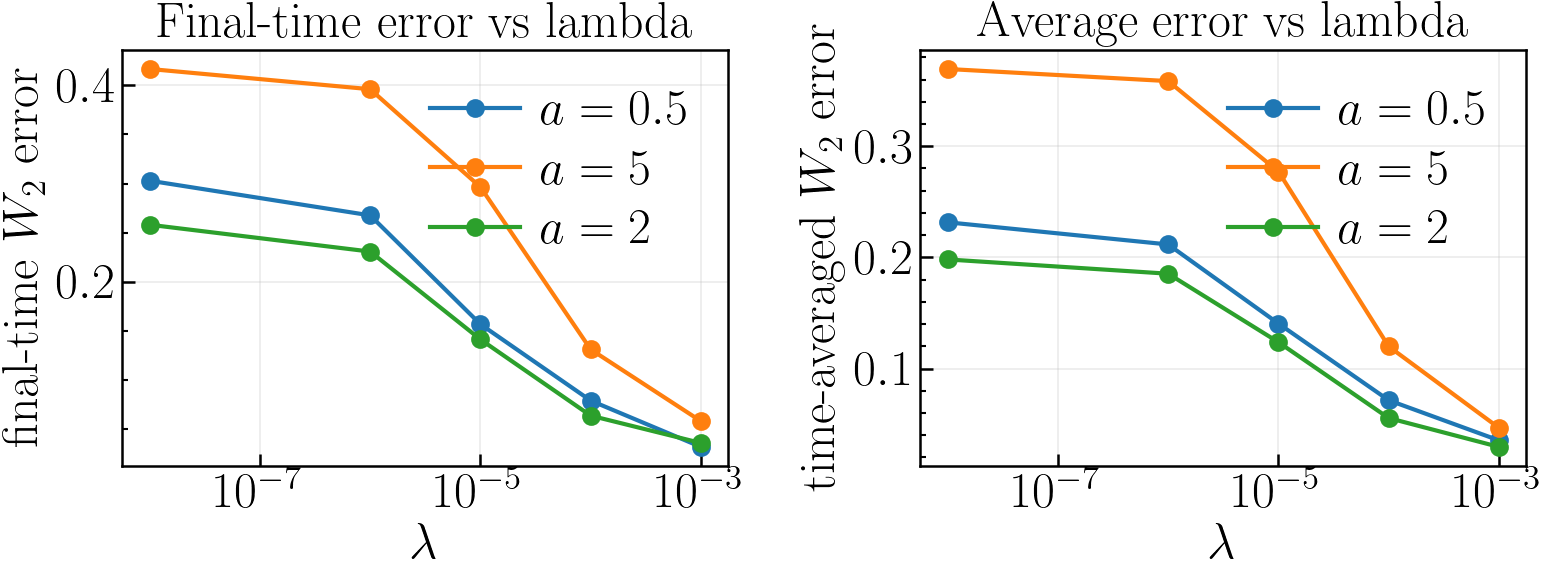

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# settings
# ----------------------------
a_list = [
    ("a_5p000e-01", r"$a=0.5$"),
    ("a_5p000e00",  r"$a=5$"),
    ("a_2p000e00",  r"$a=2$"),
]

lambda_list = [
    ("001_0p000e00", 0.0,    "0"),
    ("003_1p000e-06", 1e-6,  "1e-6"),
    ("004_1p000e-05", 1e-5,  "1e-5"),
    ("005_1p000e-04", 1e-4,  "1e-4"),
    ("006_1p000e-03", 1e-3,  "1e-3"),
]

nudge = 20

# ----------------------------
# 1D exact W2 for equal-weight empirical measures
# ----------------------------
def w2_1d_empirical(x, y):
    x = np.sort(np.asarray(x).reshape(-1))
    y = np.sort(np.asarray(y).reshape(-1))
    if len(x) != len(y):
        raise ValueError("x and y must have the same number of samples for this formula.")
    return np.sqrt(np.mean((x - y) ** 2))

def compute_w2_time_series(x_true, x_est):
    T = min(x_true.shape[0], x_est.shape[0])
    w2 = np.zeros(T)
    for t in range(T):
        w2[t] = w2_1d_empirical(x_true[t, :], x_est[t, :])
    return w2

# ----------------------------
# plotting
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax_final, ax_avg = axes

for a_dir, a_label in a_list:
    # true data for this a
    true_path = f"../case1d/simulation/data/mv_sim_seed0.npz"
    data_true = np.load(true_path)
    x_true = data_true["x_paths"]

    lambda_vals = []
    final_errors = []
    avg_errors = []

    for lam_str, lam_val, lam_label in lambda_list:
        path = (
            f"../case1d/assimilation/data/lambda_scan_parameter_grid/"
            f"{a_dir}__nudge_iters_{nudge:03d}/lambda_scan/runs/"
            f"lambda_{lam_str}/x_da_kdenudge_1d_seed0.npz"
        )

        data = np.load(path)
        x_est = data["x_est"]

        w2_t = compute_w2_time_series(x_true, x_est)

        lambda_vals.append(lam_val if lam_val > 0 else 1e-8)  # 为了 log-x 画图
        final_errors.append(w2_t[-1])
        avg_errors.append(np.mean(w2_t))

    ax_final.plot(lambda_vals, final_errors, marker="o", linewidth=2, label=a_label)
    ax_avg.plot(lambda_vals, avg_errors, marker="o", linewidth=2, label=a_label)

ax_final.set_xscale("log")
ax_avg.set_xscale("log")

ax_final.set_xlabel(r"$\lambda$")
ax_avg.set_xlabel(r"$\lambda$")

ax_final.set_ylabel(r"final-time $W_2$ error")
ax_avg.set_ylabel(r"time-averaged $W_2$ error")

ax_final.set_title("Final-time error vs lambda")
ax_avg.set_title("Average error vs lambda")

ax_final.grid(alpha=0.25)
ax_avg.grid(alpha=0.25)

ax_final.legend(frameon=False)
ax_avg.legend(frameon=False)

plt.tight_layout()
plt.savefig("w2_vs_lambda_iter20.png", dpi=300, bbox_inches="tight")
plt.savefig("w2_vs_lambda_iter20.pdf", dpi=300, bbox_inches="tight")
plt.show()

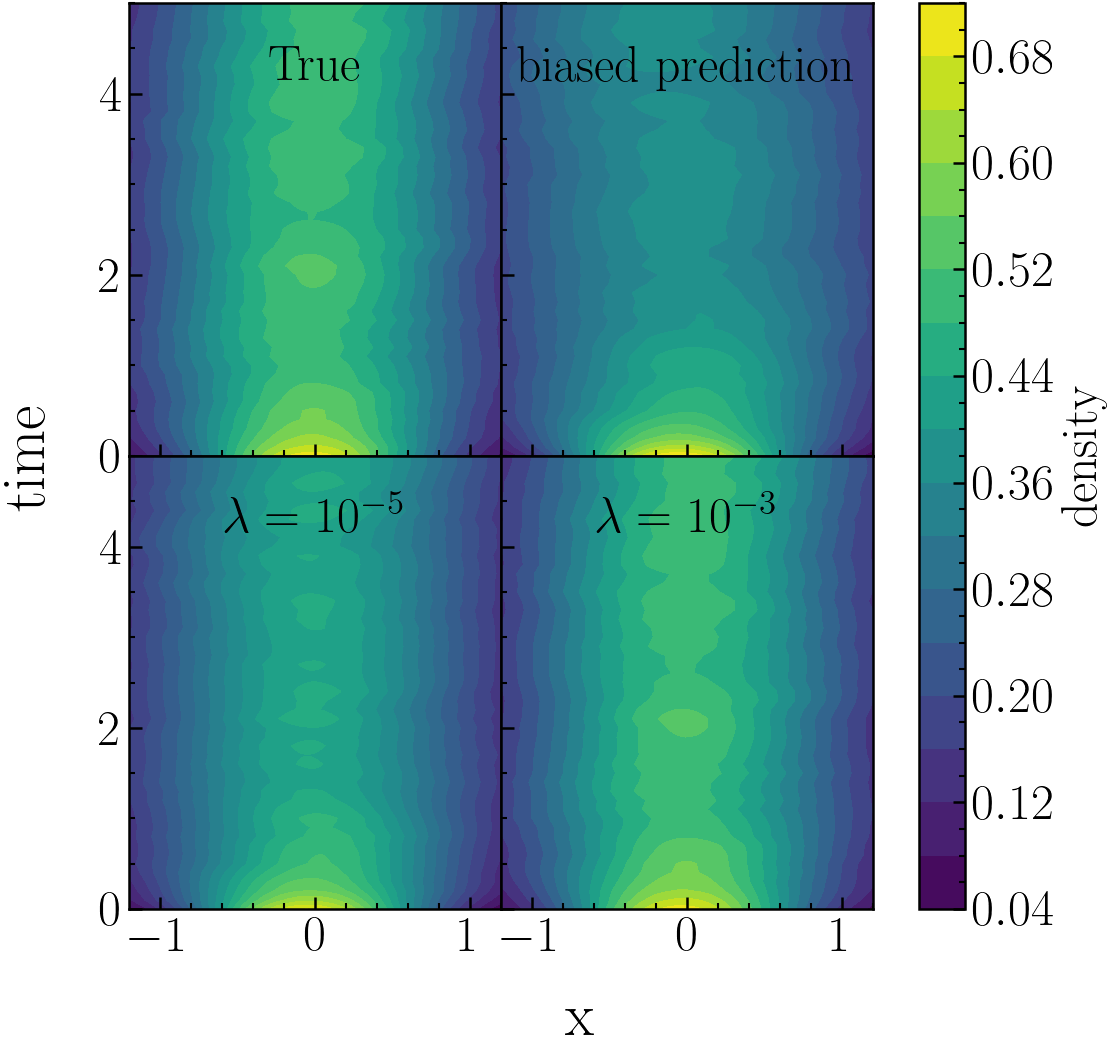

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(
    2, 2, figsize=(8, 8), sharex=True, sharey=True,
    gridspec_kw={"wspace": 0, "hspace": 0}
)

x_grid = np.linspace(-1.2, 1.2, 100)
axes = axes.flatten()

def compute_kde_time(x):
    kde_time = []
    for t in range(0,x.shape[0],10):
        kde = gaussian_kde(x[t:t+10, :].reshape(-1), bw_method=0.5)
        kde_time.append(kde(x_grid))
    return np.array(kde_time)

def plot_contour(ax, kde_time, title=None):
    T = np.arange(kde_time.shape[0])*0.1
    X, TT = np.meshgrid(x_grid, T)

    cf = ax.contourf(X, TT, kde_time, levels=20)
    ax.set_yticks([0.0,2,4])
    if title:
        ax.set_title(title,y=0.8)
    return cf

# --- subplot 1: true ---
data_true = np.load("../case1d/simulation/data/mv_sim_seed0.npz")
x = data_true["x_paths"]
kde_time = compute_kde_time(x)
cf = plot_contour(axes[0], kde_time, "True")

# --- subplot 2 ---
data = np.load("../case1d/assimilation/data/lambda_scan_parameter_grid/a_5p000e-01__nudge_iters_010/lambda_scan/runs/lambda_001_0p000e00/x_da_kdenudge_1d_seed0.npz")
x = data["x_est"]
kde_time = compute_kde_time(x)
plot_contour(axes[1], kde_time, r"biased prediction")

# --- subplot 3 ---
data = np.load("../case1d/assimilation/data/lambda_scan_parameter_grid/a_5p000e-01__nudge_iters_010/lambda_scan/runs/lambda_004_1p000e-05/x_da_kdenudge_1d_seed0.npz")
x = data["x_est"]
kde_time = compute_kde_time(x)
plot_contour(axes[2], kde_time, r"$\lambda=10^{-5}$")

# --- subplot 4 ---
data = np.load("../case1d/assimilation/data/lambda_scan_parameter_grid/a_5p000e-01__nudge_iters_010/lambda_scan/runs/lambda_006_1p000e-03/x_da_kdenudge_1d_seed0.npz")
x = data["x_est"]
kde_time = compute_kde_time(x)
plot_contour(axes[3], kde_time, r"$\lambda=10^{-3}$")


# --- colorbar（统一）---
fig.colorbar(cf, ax=axes, label="density")

fig.supxlabel("x")
fig.supylabel("time")
plt.savefig("1d_case_density_a_0.5.pdf",dpi=600)
plt.savefig("1d_case_density_a_0.5.png",dpi=600)

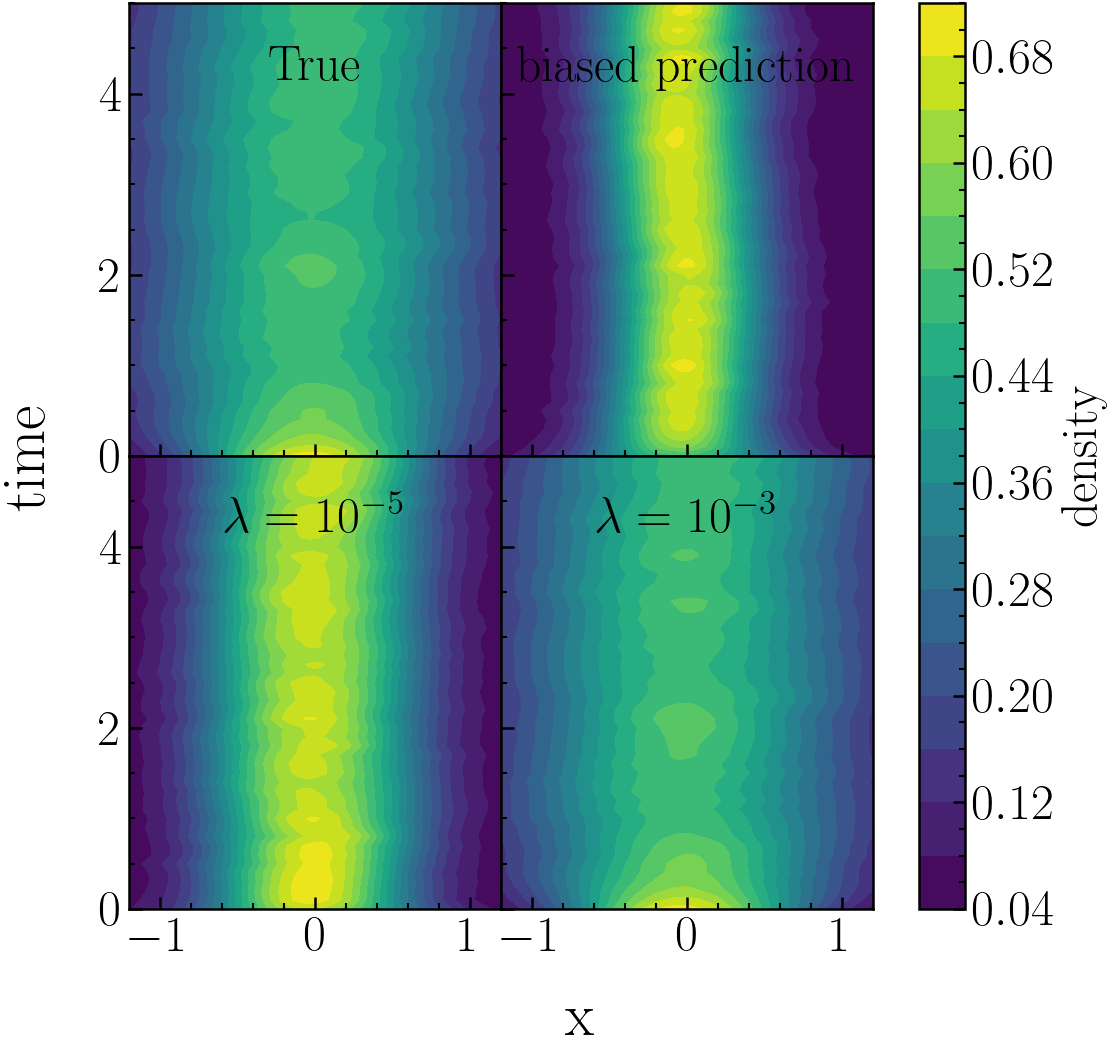

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(
    2, 2, figsize=(8, 8), sharex=True, sharey=True,
    gridspec_kw={"wspace": 0, "hspace": 0}
)

x_grid = np.linspace(-1.2, 1.2, 100)
axes = axes.flatten()

def compute_kde_time(x):
    kde_time = []
    for t in range(0,x.shape[0],10):
        kde = gaussian_kde(x[t:t+10, :].reshape(-1), bw_method=0.5)
        kde_time.append(kde(x_grid))
    return np.array(kde_time)

def plot_contour(ax, kde_time, title=None):
    T = np.arange(kde_time.shape[0])*0.1
    X, TT = np.meshgrid(x_grid, T)

    cf = ax.contourf(X, TT, kde_time, levels=20)
    ax.set_yticks([0.0,2,4])
    if title:
        ax.set_title(title,y=0.8)
    return cf

# --- subplot 1: true ---
data_true = np.load("../case1d/simulation/data/mv_sim_seed0.npz")
x = data_true["x_paths"]
kde_time = compute_kde_time(x)
cf = plot_contour(axes[0], kde_time, "True")

# --- subplot 2 ---
data = np.load("../case1d/assimilation/data/lambda_scan_parameter_grid/a_5p000e00__nudge_iters_010/lambda_scan/runs/lambda_001_0p000e00/x_da_kdenudge_1d_seed0.npz")
x = data["x_est"]
kde_time = compute_kde_time(x)
plot_contour(axes[1], kde_time, r"biased prediction")

# --- subplot 3 ---
data = np.load("../case1d/assimilation/data/lambda_scan_parameter_grid/a_5p000e00__nudge_iters_010/lambda_scan/runs/lambda_004_1p000e-05/x_da_kdenudge_1d_seed0.npz")
x = data["x_est"]
kde_time = compute_kde_time(x)
plot_contour(axes[2], kde_time, r"$\lambda=10^{-5}$")

# --- subplot 4 ---
data = np.load("../case1d/assimilation/data/lambda_scan_parameter_grid/a_5p000e00__nudge_iters_010/lambda_scan/runs/lambda_006_1p000e-03/x_da_kdenudge_1d_seed0.npz")
x = data["x_est"]
kde_time = compute_kde_time(x)
plot_contour(axes[3], kde_time, r"$\lambda=10^{-3}$")


# --- colorbar（统一）---
fig.colorbar(cf, ax=axes, label="density")

fig.supxlabel("x")
fig.supylabel("time")
plt.savefig("1d_case_density_a_5.pdf",dpi=600)
plt.savefig("1d_case_density_a_5.png",dpi=600)

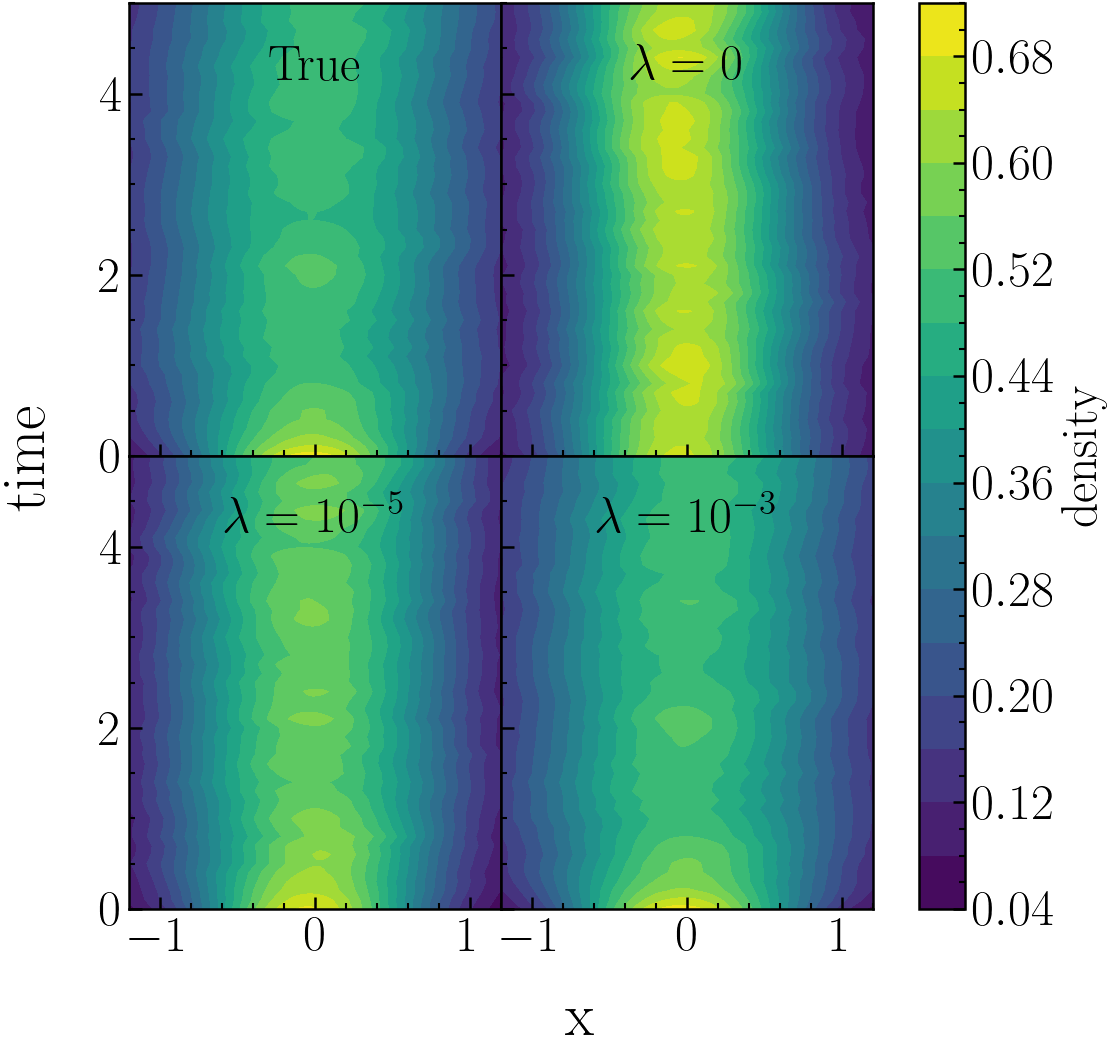

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(
    2, 2, figsize=(8, 8), sharex=True, sharey=True,
    gridspec_kw={"wspace": 0, "hspace": 0}
)

x_grid = np.linspace(-1.2, 1.2, 100)
axes = axes.flatten()

def compute_kde_time(x):
    kde_time = []
    for t in range(0,x.shape[0],10):
        kde = gaussian_kde(x[t:t+10, :].reshape(-1), bw_method=0.5)
        kde_time.append(kde(x_grid))
    return np.array(kde_time)

def plot_contour(ax, kde_time, title=None):
    T = np.arange(kde_time.shape[0])*0.1
    X, TT = np.meshgrid(x_grid, T)

    cf = ax.contourf(X, TT, kde_time, levels=20)
    ax.set_yticks([0.0,2,4])
    if title:
        ax.set_title(title,y=0.8)
    return cf

# --- subplot 1: true ---
data_true = np.load("../case1d/simulation/data/mv_sim_seed0.npz")
x = data_true["x_paths"]
kde_time = compute_kde_time(x)
cf = plot_contour(axes[0], kde_time, "True")

# --- subplot 2 ---
data = np.load("../case1d/assimilation/data/lambda_scan_parameter_grid/a_2p000e00__nudge_iters_010/lambda_scan/runs/lambda_001_0p000e00/x_da_kdenudge_1d_seed0.npz")
x = data["x_est"]
kde_time = compute_kde_time(x)
plot_contour(axes[1], kde_time, r"$\lambda=0$")

# --- subplot 3 ---
data = np.load("../case1d/assimilation/data/lambda_scan_parameter_grid/a_2p000e00__nudge_iters_010/lambda_scan/runs/lambda_004_1p000e-05/x_da_kdenudge_1d_seed0.npz")
x = data["x_est"]
kde_time = compute_kde_time(x)
plot_contour(axes[2], kde_time, r"$\lambda=10^{-5}$")

# --- subplot 4 ---
data = np.load("../case1d/assimilation/data/lambda_scan_parameter_grid/a_2p000e00__nudge_iters_010/lambda_scan/runs/lambda_006_1p000e-03/x_da_kdenudge_1d_seed0.npz")
x = data["x_est"]
kde_time = compute_kde_time(x)
plot_contour(axes[3], kde_time, r"$\lambda=10^{-3}$")


# --- colorbar（统一）---
fig.colorbar(cf, ax=axes, label="density")

fig.supxlabel("x")
fig.supylabel("time")
plt.savefig("1d_case_density_a_2.pdf",dpi=600)
plt.savefig("1d_case_density_a_2.png",dpi=600)

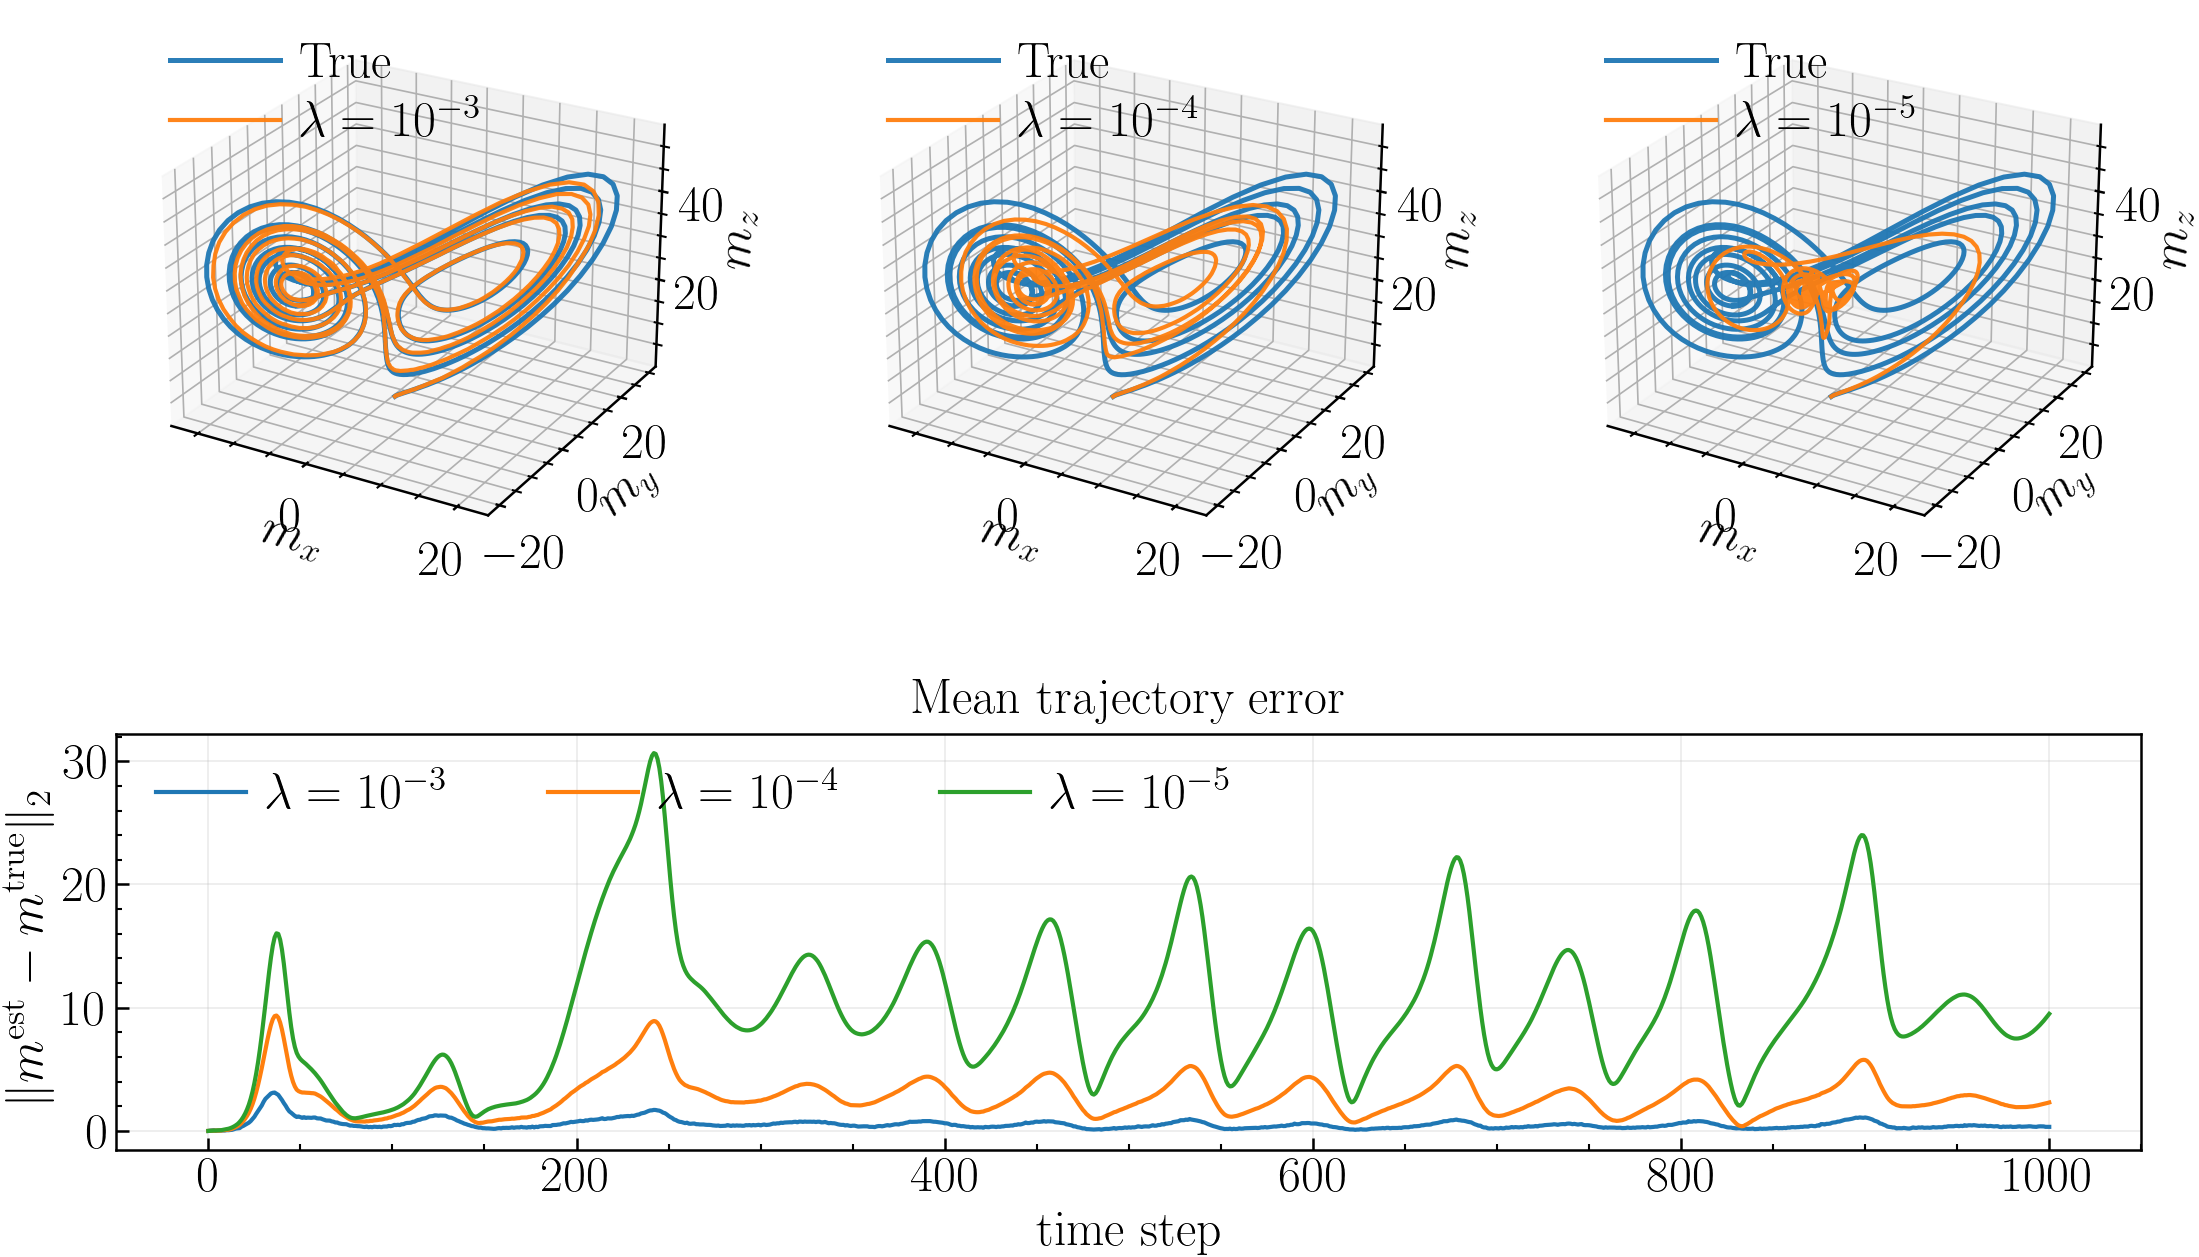

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ----------------------------
# load true trajectory
# ----------------------------
data_true = np.load("../case2_mean_field_Lorenz/simulation/data/mv_sim_seed0.npz")
m_true = data_true["means"][:1001]   # shape (T, 3)
mx_true, my_true, mz_true = m_true[:, 0], m_true[:, 1], m_true[:, 2]

# ----------------------------
# load estimated trajectories
# ----------------------------
paths = {
    r"$\lambda=10^{-3}$": "../case2_mean_field_Lorenz/assimilation/data_lambda_1e_3/xyz_da_kdenudge_3d_seed0.npz",
    r"$\lambda=10^{-4}$": "../case2_mean_field_Lorenz/assimilation/data_lambda_1e_4/xyz_da_kdenudge_3d_seed0.npz",
    r"$\lambda=10^{-5}$": "../case2_mean_field_Lorenz/assimilation/data_lambda_1e_5/xyz_da_kdenudge_3d_seed0.npz",
}

est_data = {}
errors = {}

for label, path in paths.items():
    data = np.load(path)
    m_est = np.column_stack([data["mx_est"], data["my_est"], data["mz_est"]])
    est_data[label] = m_est
    errors[label] = np.linalg.norm(m_est - m_true, axis=1)

labels = list(est_data.keys())
t = np.arange(m_true.shape[0])


# 只画前一段轨道通常更容易比较
nplot = 1000   # 也可以改成 m_true.shape[0]

# ----------------------------
# figure layout
# ----------------------------
fig = plt.figure(figsize=(15, 9))
gs = GridSpec(
    2, 3,
    figure=fig,
    height_ratios=[1.35, 1.0],   # 上排更高
    hspace=0.35,
    wspace=0.22
)

# ----------------------------
# top row: 3D comparisons
# ----------------------------
for i, label in enumerate(labels):
    ax = fig.add_subplot(gs[0, i], projection="3d")
    m_est = est_data[label]

    ax.plot(
        mx_true[:nplot], my_true[:nplot], mz_true[:nplot],
        lw=2.4, alpha=0.95, label="True"
    )
    ax.plot(
        m_est[:nplot, 0], m_est[:nplot, 1], m_est[:nplot, 2],
        lw=2.0, alpha=0.95, label=label
    )

    # ax.set_title(label, pad=14)
    ax.set_xlabel(r"$m_x$", labelpad=2)
    ax.set_ylabel(r"$m_y$", labelpad=2)
    ax.set_zlabel(r"$m_z$", labelpad=2)
    ax.view_init(elev=25, azim=-60)

    # 每个子图一个小 legend，避免全局 legend 挤坏布局
    ax.legend(loc="upper left", frameon=False, handlelength=2.2)

# ----------------------------
# bottom row: error plot
# ----------------------------
ax_err = fig.add_subplot(gs[1, :])

for label in labels:
    ax_err.plot(t, errors[label], lw=2.0, label=label)

ax_err.set_xlabel("time step")
ax_err.set_ylabel(r"$\|m^{\mathrm{est}} - m^{\mathrm{true}}\|_2$")
ax_err.set_title("Mean trajectory error", pad=10)
ax_err.legend(frameon=False, ncol=3, loc="upper left")
ax_err.grid(alpha=0.25)

# ----------------------------
# final spacing
# ----------------------------
fig.subplots_adjust(top=0.93, bottom=0.08, left=0.08, right=0.98)

plt.savefig("lorenz_lambda_comparison.png", dpi=300, bbox_inches="tight")